# Проект: Продвинутые техники подготовки данных

**Описание проекта:** В данной работе я изучаю продвинутые техники обработки данных, чтобы оценить их влияние на точность прогноза модели, выявить моменты, которые могут вызывать сложности, какие шаги могут быть излишними, и сравнить, на сколько такие техники улучшают качество модели.

**Цель проекта:** Разработать и обучить модели машинного обучения для предсказания медианной стоимости дома в жилых массивах Калифорнии на основе различных комбинаций признаков, используя продвинутые техники к предобработке и подготовке данных, а так же отбора оптимального набора признаков для обучения модели.

**Описание данных:**

`california_housing_prices.csv` — данные о жилье в Калифорнии 1990 года.

[🔗Ссылка на датасет](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

**Описание признаков:**

- `longitude` — долгота;
- `latitude` — широта;
- `housing_median_age` — медианный возраст дома в пределах квартала *(меньшее число - это более новое здание)*;
- `total_rooms` — общее количество комнат в домах жилого массива;
- `total_bedrooms` — общее количество спален в домах жилого массива;
- `population` — количество человек, которые проживают в жилом массиве;
- `households` — количество домовладений в жилом массиве;
- `median_income` — медианный доход жителей жилого массива *(единица измерения 10.000 US Dollars)*;
- `median_house_value` — медианная стоимость дома в жилом массиве *(**Целевой признак** / единица измерения US Dollars)*;
- `ocean_proximity` — близость к океану.

**Ход исследования:**

- `Подготовка данных`: загрузка и изучение общей информации из представленного датасета;

  
- `Предобработка данных`: заполнение пропущенных значений методом `MICE`, корректировка типов данных, проверка на наличие явных/неявных дубликатов;


- `Исследовательский анализ данных`: изучение признаков имеющихся в датасетах, их распределение, поиск выбросов/аномалий в данных, а так же применения к ним собственного алгоритма `compress`, для снижения их влияния;


- `Feature engineering`: **В процессе.**


- `Корреляционный анализ`: 


- `Подготовка данных`:


- `Обучение моделей`:


- `Анализ результатов`:


- `Общий вывод`:

## Подготовка рабочей среды:

### Импорт библиотек:

In [1]:
import numpy as np
import math
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import anderson
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import phik
import shap
import miceforest as mf
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import FastICA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import (StandardScaler, 
                                   OneHotEncoder, 
                                   FunctionTransformer)
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import RFE

### Базовые настройки блокнота:

In [2]:
# Стиль графиков по умолчанию
sns.set()
sns.set_context('notebook')
# Убираем ограничения на количество колонок
pd.set_option('display.max_column', None)
# Убираем ограничение на количество символов в ячейках
pd.set_option('display.max_colwidth', None)
# Константа для random_state
RANDOM_STATE = 6011994

### Функции:

In [3]:
# Функция для получения общей информации о датафрейме
def gen_info(df):
    '''
    Данная функция выводит общую информацию 
    о датафрейме, статистическое описание признаков
    и 5 рандомных строк.
    На ввод функция принимает переменную датафрейма.
    '''
    # Статистики по количественным признакам
    desc = df.describe().T

    # Подсчет коэффициента вариативности значений
    desc['cv_coef'] = desc['std'] / desc['mean']

    # Вывод результатов
    print(df.info())
    display(desc)
    display(df.sample(5, random_state=RANDOM_STATE))

In [4]:
# Функция для поиска неявных дубликатов
def hidden_dup_search(df):
    '''
    Данная функция приводит значения категориальных 
    столбцов к единому стилю и выводит их уникальные 
    значения.
    На ввод функция принимает переменную датафрейма.
    '''
    
    # Список категориальных признаков
    df_cat_col = df.select_dtypes(exclude = 'number').columns.tolist()

    # Приводим все значения к единому стилю
    # и проверяем уникальные значения для 
    # точечной проработки при необходимости
    for feature in df_cat_col:
        df[feature] = df[feature].str.lower().str.replace(' ', '_')
        print(f'Уникальные значения признака: {str(feature)}')
        print(df[feature].unique())
        print()

In [5]:
# Функция для комплексного анализа количественного признака
def analyzis_quantity(df, x_label, y_label='Частота', target=None, 
                      hue=None, system=False, discrete=False, 
                      log_scale=False, title_hist=None, title_scatter=None):
    '''
    Данная функция выводит "коробочный" график и гистограмму 
    по указанному столбцу датафрейма и его статистические метрики.
    Аргументы функции:
    df - данные (pd.Series)
    x_label - подпись для оси Х
    y_label - подпись для оси Y (по умолчанию "Частота")
    target - целевая переменная для scatter-графика (если system=True)
    hue - переменная для цветового кодирования (если system=True)
    system - флаг для построения scatter-графика
    discrete - булевое значение, дискретные значение или нет.
    log_scale - логарифмическая шкала для гистограммы
    title_hist - заголовок для гистограммы и boxplot
    title_scatter - заголовок для scatter-графика
    '''

    # Названия для графиков по умолчанию
    if title_hist is None:
        title_hist = f"Распределение {df.name if hasattr(df, 'name') else 'входной признак'}"
    if title_scatter is None:
        target_name = target.name if hasattr(target, 'name') else 'таргета'
        feature_name = df.name if hasattr(df, 'name') else 'входной признак'
        title_scatter = f"Зависимость {target_name} от {feature_name}"
    
    # Создание составного графика: boxplot + histogram
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                          figsize=(6, 4.2), 
                                          gridspec_kw={'height_ratios': (.15, .85)})
    
    # Boxplot
    sns.boxplot(x=df, orient='h', ax=ax_box)
    ax_box.set(xlabel='')

    # Histogram
    n_bins = round(1 + math.log2(len(df))) if len(df) > 1 else 10
    sns.histplot(x=df, bins=n_bins, discrete=discrete, log_scale=log_scale, ax=ax_hist)

    # Общие настройки для основной фигуры
    ax_hist.set_xlabel(x_label, fontsize=10)
    ax_hist.set_ylabel(y_label, fontsize=10)
    ax_hist.tick_params(axis='both', which='major', labelsize=10)
    fig.suptitle(title_hist, fontsize=12, fontweight='bold', y=0.95)

    # Настройка тиков для дискретных значений
    if discrete:
        ax_hist.set_xticks(np.arange(df.min(), df.max() + 1, 1))

    # Отображение первой фигуры
    fig.tight_layout()

    # Scatter plot (если запрошено)
    if system:
        if hue is not None:
            fig_2, ax_2 = plt.subplots(figsize=(7.5, 4))
        else:
            fig_2, ax_2 = plt.subplots(figsize=(6, 4))
        sns.scatterplot(x=df, y=target, alpha=0.5, hue=hue, ax=ax_2)
        fig_2.suptitle(title_scatter, fontsize=12, fontweight='bold', y=0.95)
        ax_2.set_xlabel(x_label, fontsize=10)
        ax_2.set_ylabel(target.name if hasattr(target, 'name') else 'Целевая переменная', fontsize=10)
        ax_2.tick_params(axis='both', which='major', labelsize=10)
        if hue is not None:
            ax_2.legend(bbox_to_anchor=(1.025, 1), loc='upper left', fontsize=10)
        fig_2.tight_layout()

    # Отображение графика
    plt.show()

    # Вывод статистических метрик
    display(df.describe().to_frame().T)
        
    # Проверяем нормальность распределения
    result = anderson(df.dropna())
    
    if result.statistic < result.critical_values[2]:
        distr = 'Нормальное'
    else:
        distr = 'Не является нормальным'

    test_anderson = {'':['Статистика:', 
                         "Критические значения:", 
                         'Распределение'], 
                     'Тест на нормальность распределения (порог=0.05):': [result.statistic, 
                                                                          result.critical_values, 
                                                                          distr]
                    }
    display(pd.DataFrame(test_anderson).set_index(''))

In [6]:
# Функция для анализа категорийных значений

def analyzis_category(df, title=None, kind='bar'):
    '''
    Данная функция выводит столбчатый график
    по указанному столбцу датафрейма и его значения 
    в табличном виде.
    Аргументы функции:
    df - данные
    name - название графика
    kind - ориентация графика вертикальная или 
    горизонтальная, принимает значения "bar" и "barh".
    '''
    # Название для графика по умолчанию
    if title is None:
        title = f"Соотношение категорий {df.name if hasattr(df, 'name') else 'входного признака'}"
    
    # Подсчитываем количество каждого значения
    category_count = df.value_counts(ascending=True)

    # Создание столбчатого графика
    plot_bar = category_count.plot(kind=kind, figsize=(6, 4), grid=True)

    # Настройка заголовка и подписей
    if kind == 'bar':
        plt.title(title, fontweight='bold', fontsize=12)
        plt.xlabel('')
        plt.ylabel('Частота', fontsize=10)
        plt.tick_params(axis='both', which='major', labelsize=10)
        plt.xticks(rotation=0)
    
    else:
        plt.title(title, fontweight='bold', fontsize=12)
        plt.xlabel('Частота', fontsize=10)
        plt.ylabel('')
        plt.tick_params(axis='both', which='major', labelsize=10)
        plt.xticks(rotation=0)

    # Отображаем график
    plt.tight_layout()
    plt.show()

    # Вывод значений в табличном виде
    display(pd.DataFrame(category_count).reset_index().style.hide(axis='index'))

In [7]:
# Построение таблицы с расчитанным VIF
def vif_factor(data, columns):
    '''
    Данная функция расчитываем VIF-фактор
    для количественных признаков датафрейма.
    На ввод функция принимает:
    data - датафрейм
    columns - список количественных признаков.
    '''
    vif_data = pd.DataFrame()
    vif_data['input attribute'] = columns
    vif_data['vif'] = ([variance_inflation_factor(data[columns].values, i) 
                        for i in range(data[columns].shape[1])])
    return vif_data

In [8]:
# Функция для компрессии данных
def compress(df, threshold, coef, method='power', dry=0):
    '''
    Функция для степенной копрессии данных,
    пики превышающие порог масштабируются c
    соответствнно размеру коэффициента.
    
    Аргументы:
    df - pd.Series (оригинальный признак для компрессии);
    threshold - порог срабатывания компрессора (передавать абсолютные значение);
    coef - степень сжатия (для метода power), 
    коэффициент ослабления силы сжатия (для метода log);
    method - метод сжатия (степенной - power, логарифмический - log);
    dry - доля подмешивания оригинальных значений, для ослабления сжатия.

    Вывод: pd.Series.
    '''
    mask = df > threshold
    compress_col = df.copy().astype('float64')
    
    if method == 'power':
        
        compress_col[mask] = threshold + (df[mask] - threshold) ** coef
    
    elif method == 'log':
        
        compress_col[mask] = threshold + np.log1p(df[mask] - threshold) * coef
    
    else:
        raise ValueError(f"Неподдерживаемый метод: '{method}'. Допустимые значения: 'power', 'log'")
    
    return df * dry + compress_col * (1 - dry)

In [9]:
# Функция для преобразования значений долготы и широты в 3д координаты
def to_3d(lat, lon):
    '''
    Данная функция преобразовывает значения 
    долготы и широты в массив с 3д координатами
    этих точек.
    Аргументы:
    lat - широта
    lon - долгота

    Вывод: массив 3д координат (np.array).
    '''
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return np.array([x, y, z]).T

In [12]:
# Функция для исправления порядка категорий в urban_area
def order_urban_area(x):
    if x == 0:
        return x
    elif x == 2:
        return 1
    elif x == 1:
        return 2
    elif x == 4:
        return 3
    else:
        return 4

## Общая информация о данных:

### Загрузка данных:

In [13]:
df = pd.read_csv('./housing.csv')

### Знакомство с данными:

In [14]:
gen_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


,count,mean,std,min,25%,50%,75%,max,cv_coef
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100,-0.016756
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500,0.059945
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000,0.439448
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000,0.827698
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000,0.783432
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000,0.794444
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000,0.765364
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001,0.490825
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000,0.557855


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
15688,-122.43,37.79,52.0,3486.0,847.0,1248.0,813.0,7.2623,500001.0,NEAR BAY
8874,-118.45,34.06,52.0,204.0,34.0,1154.0,28.0,9.3370,500001.0,<1H OCEAN
7813,-118.11,33.90,35.0,2604.0,495.0,1465.0,470.0,4.4896,184600.0,<1H OCEAN
3994,-118.57,34.17,35.0,2072.0,318.0,908.0,342.0,6.0928,327300.0,<1H OCEAN
11439,-117.98,33.61,17.0,2054.0,291.0,836.0,288.0,6.8939,383900.0,NEAR OCEAN


### Вывод:

В данном разделе мы познакомились с общей информацией о датафрейме, теперь можем приблизительно составить план для предобработки данных и дальнейшей работе:

- Строки с пропущенными значениями надо рассмотреть и понять природу их возникновения, по возможности их восстановить, но их количество не так велико *(около 1%)*, если там будет наблюдатся сложная зависимость, имеет смысл просто от них отказаться, чтобы не снижать качество данных;
- После заполнения или удаления пропусков можем часть признаков преобразовать в целочисленные типы данных;
- Изменим масштаб значений признака `median_income` в изначальный вид, для удобства восприятия *(умножим на 10000)*;
- Необходимо данные проверить на наличие явных и неявных дубликатов.

## Предобработка данных:

### Пропущенные значения:

Рассмотрим строки с пропущенными значениям и попытаемся понять природу их возникновения.

In [15]:
df_na = df.query('total_bedrooms.isna()')

In [16]:
df_na.sample(15, random_state=RANDOM_STATE)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
18346,-122.15,37.43,20.0,11709.0,NaN,7604.0,3589.0,1.9045,375000.0,NEAR BAY
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
6835,-118.12,34.08,35.0,2248.0,NaN,1762.0,622.0,3.0000,253900.0,<1H OCEAN
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
19391,-120.85,37.78,25.0,421.0,NaN,303.0,106.0,2.2679,71300.0,INLAND
16757,-122.48,37.70,33.0,4492.0,NaN,3477.0,1537.0,3.0546,297900.0,NEAR OCEAN
17198,-119.75,34.45,6.0,2864.0,NaN,1404.0,603.0,5.5073,263800.0,NEAR OCEAN
14386,-117.23,32.75,5.0,1824.0,NaN,892.0,426.0,3.4286,137500.0,NEAR OCEAN
5665,-118.29,33.73,30.0,3161.0,NaN,1865.0,771.0,2.7139,231700.0,NEAR OCEAN
3921,-118.56,34.20,35.0,2273.0,NaN,1431.0,403.0,4.0789,196700.0,<1H OCEAN


На данном этапе достаточно сложно выявить закономерность, по которой стоит расчитывать средние значения, заполняя пропуски медианой будет слишком поверхностно и грубо, таким образом мы снизим качество данных, поэтому принято следующее решение, применить метод `MICE` для заполнения пропусков, обычно такой метод дает более точные значения, тем не менее при обучении моделей мы рассмотрим варианты, когда пропуски просто удалены либо заполнены медианой, для сравнения результатов.

#### Применения метода MICE:

In [17]:
# Проверяем наличие неявных дубликатов в категориальных признаках
hidden_dup_search(df)

Уникальные значения признака: ocean_proximity
['near_bay' '<1h_ocean' 'inland' 'near_ocean' 'island']



Неявных дубликатов нет, можем начать подготовку данных для заполнения пропусков

In [18]:
# Разделим входные признаки от таргета
# Так как в тесте его не будет для заполнения пропусков
df_na = df.drop('median_house_value', axis=1)

In [19]:
# Преобразуем тип данных для категориальных признаков
df_na['ocean_proximity'] = df_na['ocean_proximity'].astype('category')

In [20]:
# Сбрасываем индекс для корректной работы алгоритма
df_na = df_na.reset_index(drop=True)

In [21]:
# Создаем ядро
kernel = mf.ImputationKernel(data=df_na,
                             num_datasets=4,
                             mean_match_candidates=10,
                             random_state=RANDOM_STATE)

In [22]:
# Заполням пропуски
kernel.mice(2)

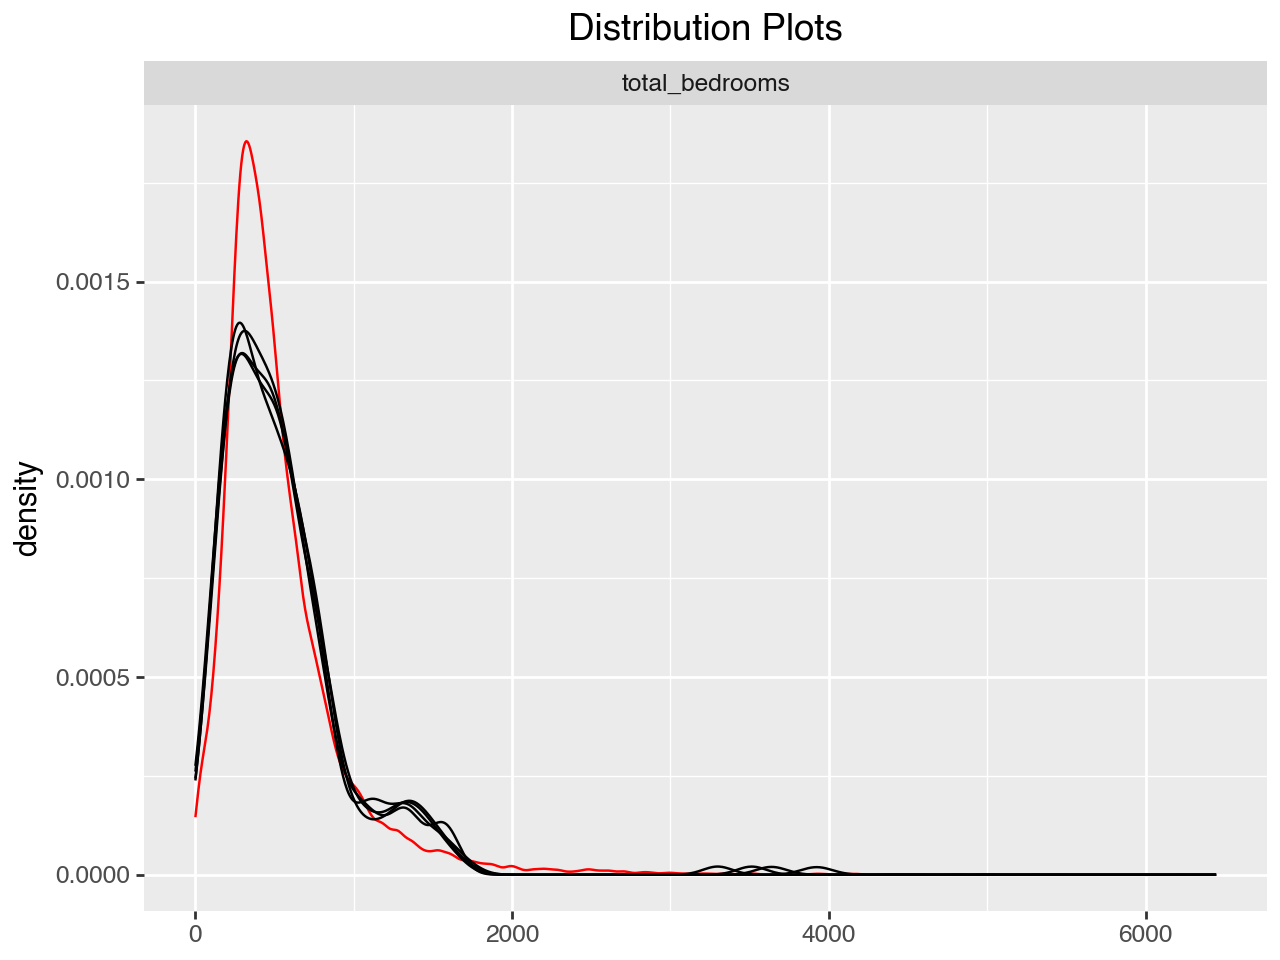

In [23]:
# Визуализация для сравнения распределения значений
kernel.plot_imputed_distributions()

По графику видим, что модель неплохо справилась с заполнением значений:

- Нет смещения;
- Хвост схож реальным распределением;
- Пик в заполненых значениях выше реального распределения, но это может быть связано с маленьким количеством пропусков.

Дополнительно проверим статистики для оригинальных и импутированных значений.

In [24]:
original = df['total_bedrooms'].dropna()
imputed = kernel.complete_data()['total_bedrooms']

print('Оригинал:')
print(f'  Среднее: {original.mean():.2f}')
print(f'  Медиана: {original.median():.2f}')
print(f'  Стандартное отклонение: {original.std():.2f}')

print('\nИмпутировано:')
print(f'  Среднее: {imputed.mean():.2f}')
print(f'  Медиана: {imputed.median():.2f}')
print(f'  Стандартное отклонение: {imputed.std():.2f}')

Оригинал:
  Среднее: 537.87
  Медиана: 435.00
  Стандартное отклонение: 421.39

Импутировано:
  Среднее: 537.92
  Медиана: 435.00
  Стандартное отклонение: 421.14


Результаты импутации показали высокую точность: среднее, медиана и стандартное отклонение импутированных значений практически совпадают с исходными. График плотности подтверждает сохранение формы распределения. Это говорит о том, что модель корректно восстановила пропущенные данные без внесения систематических искажений.

Можно с уверенностью использовать эти данные для дальнейшего анализа, визуализации и обучения моделей машинного обучения.

In [25]:
# Заменяем оригинальную на импутированную колонку
df['total_bedrooms'] = kernel.complete_data()['total_bedrooms'].set_axis(df.index)

In [26]:
# Проверяем результат
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Пропуски заполнены.

### Преобразование типов данных:

Прежде, чем преобразовывать типы данных, перепроверим все ли значения в признаках целочисленные.

In [27]:
# Предварительно восстановим масштаб признака "median_income"
df['median_income'] = df['median_income'] * 10000

In [28]:
# Список признаков для проверки
int_check = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 
             'households']

In [29]:
# Проверка, все ли значения целочисленные
for col in int_check:
    if df[col].eq(df[col].astype(int)).all():
        print(f'Признак {col} целочисленный.')
    else:
        print(f'Признак {col} имеет значения с дробной частью.')

Признак housing_median_age целочисленный.
Признак total_rooms целочисленный.
Признак total_bedrooms целочисленный.
Признак population целочисленный.
Признак households целочисленный.


In [30]:
# Преобразование типов данных:
for col in int_check:
    df[col] = df[col].astype('int')

# Проверяем результат
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20640 non-null  int64  
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


Все типы данных теперь корректны.

### Явные дубликаты:

Признак `ocean_proximity` мы уже проверили на неявные дубликаты, они там отсутствуют.

Проверим данные на наличие явных дубликатов.

In [31]:
print(f'Количество дубликатов: {df.duplicated().sum()}')

Количество дубликатов: 0


Явные дубликаты отсутствуют.

### Вывод:

На данном этапе мы выполнили следующие преобразования:

- Пропущенные значения заполнены методом `MICE` с высокой точностью;

- Типы данных преобразованы в корректные значения;

- Масштаб значений признака `median_income` изменен в изначальный, теперь он измеряется в *US Dollars*;

- Данные проверены на наличие явных и неявных дубликатов, они отсутствуют.

Теперь данные готовы для исследовательского анализа.

## Исследовательский анализ:

***Примечание:***

*К данному этапу принято решение подойти с систематическим подходом, то есть нас сразу интересует его связь таргетом. Поэтому каждый признак будет рассмотрен комплексно.*

### Количественные признаки:

In [32]:
# Переменная для целевого признака
target = df['median_house_value']

#### Признак "longitude":

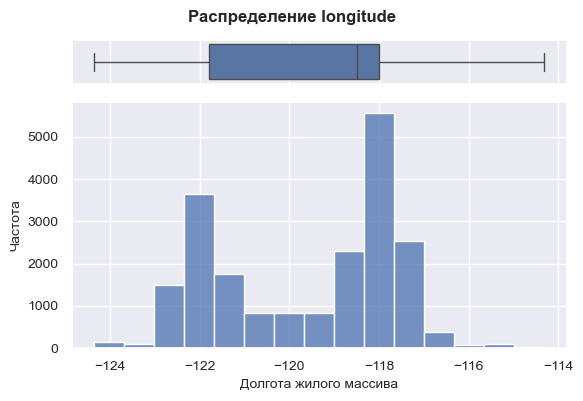

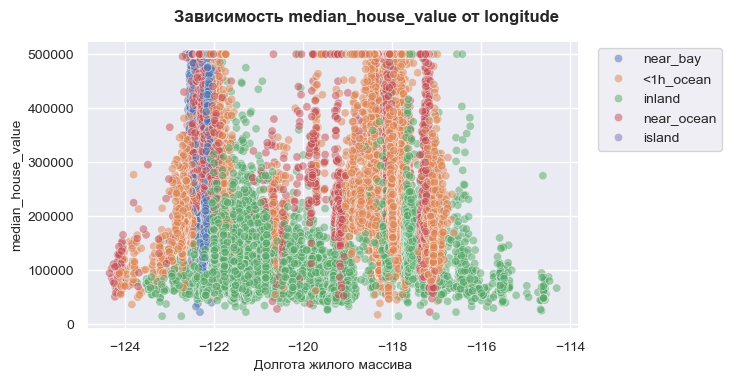

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,983.426697
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [33]:
analyzis_quantity(df['longitude'], x_label='Долгота жилого массива', target=target, system=True, hue=df['ocean_proximity'])

**Вывод:**

На графиках мы явно наблюдаем 2 района, в каждом есть как и дешевая недвижимость, так и дорогая. И они напрямую не коррелируют с категориальным признаком.

#### Признак "latitude":

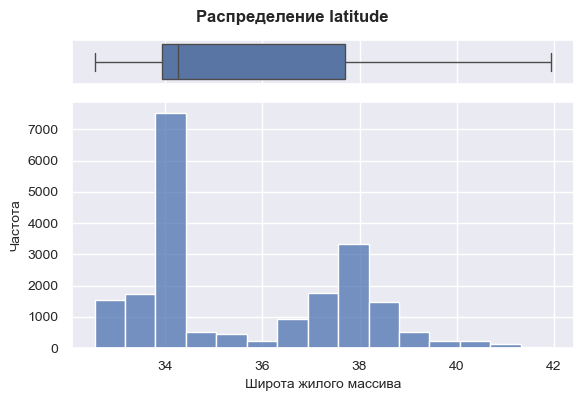

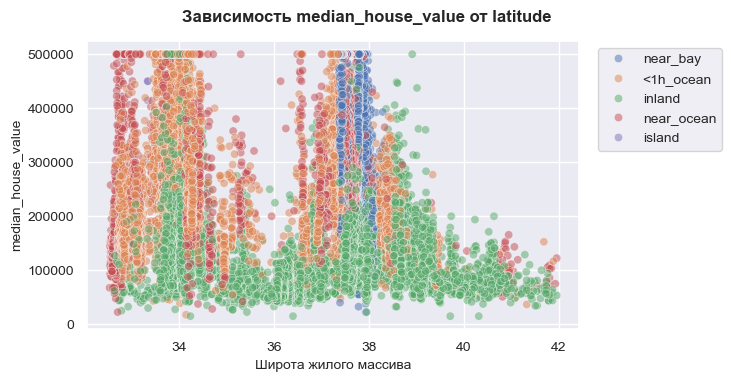

,count,mean,std,min,25%,50%,75%,max
latitude,20640.0,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,1222.728097
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [34]:
analyzis_quantity(df['latitude'], x_label='Широта жилого массива', target=target, system=True, hue=df['ocean_proximity'])

**Вывод:**

Тут мы наблюдаем ту же картину, что и с долготой, выявлено 2 района. Необходимо рассмотреть эти признаки в совокупности.

#### Признак "latitude" и "longitude":

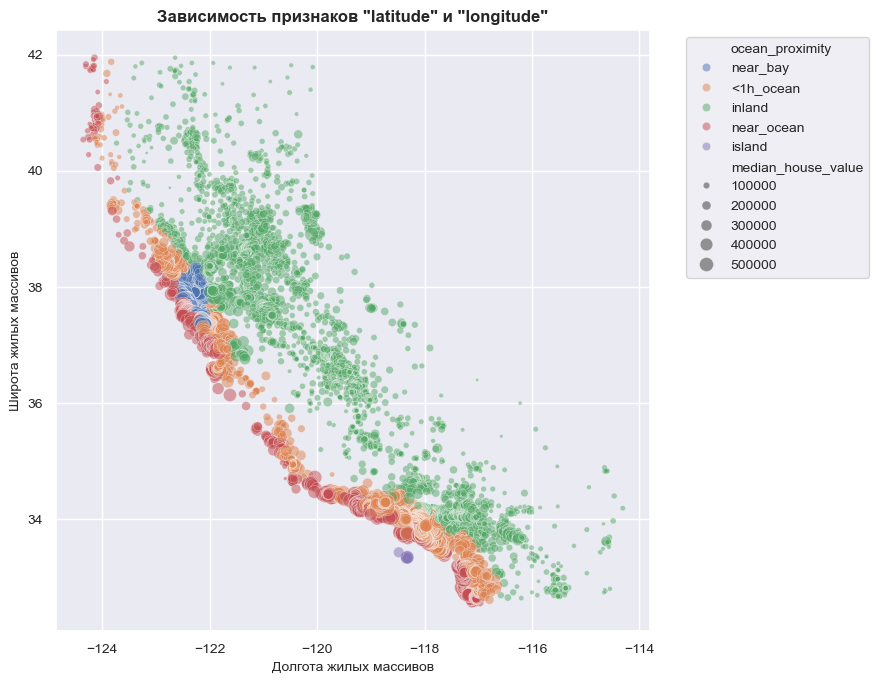

In [35]:
# Построение графика
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(x=df['longitude'], y=df['latitude'], hue=df['ocean_proximity'], size=target, sizes=(5, 100), alpha=0.5)

# Настройка заголовков и подписей
plt.title('Зависимость признаков "latitude" и "longitude"', fontsize=12, fontweight='bold')
ax.set_xlabel('Долгота жилых массивов', fontsize=10)
ax.set_ylabel('Широта жилых массивов', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Отображение графика
fig.tight_layout()
plt.show()

![Карта Калифорнии](images/california_map.jpg)

Мы видим, что скопление жилых массивов связаны с местоположением городов, тем самым мы можем разделить наши жилые массивы либо на кластеры, либо поделить на квадраты, чтобы помочь модели определять район, так как размер точек говорит о том, что местоположение жилого массива помимо близости к океану влияет на медианную цену недвижимости.

К данному вопросу вернемся на этапе корреляционного анализа.

#### Признак "housing_median_age":

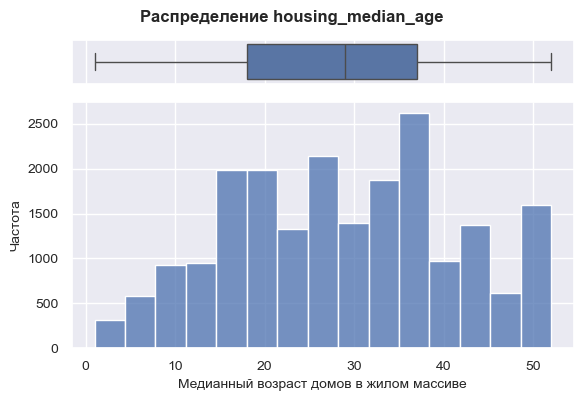

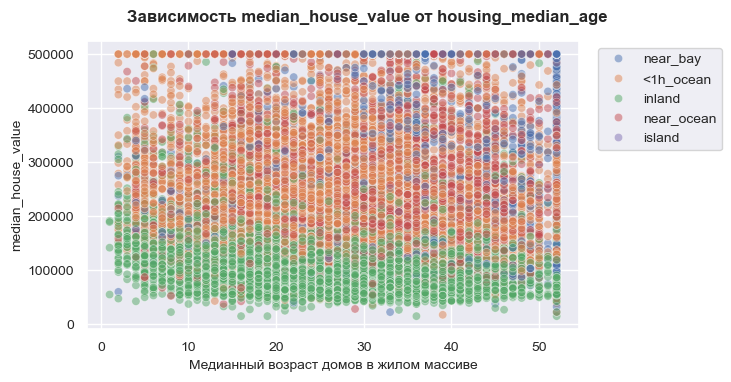

,count,mean,std,min,25%,50%,75%,max
housing_median_age,20640.0,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,88.016061
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [36]:
analyzis_quantity(df['housing_median_age'], x_label='Медианный возраст домов в жилом массиве', 
                  target=target, system=True, hue=df['ocean_proximity'])

Данный признак выглядит достаточно зашумленно, но тем не менее можно наблюдать некоторые зависимости, например то, что медианная цена в новых жилых массивах стремиться к средним значениям.

#### Признак "total_rooms":

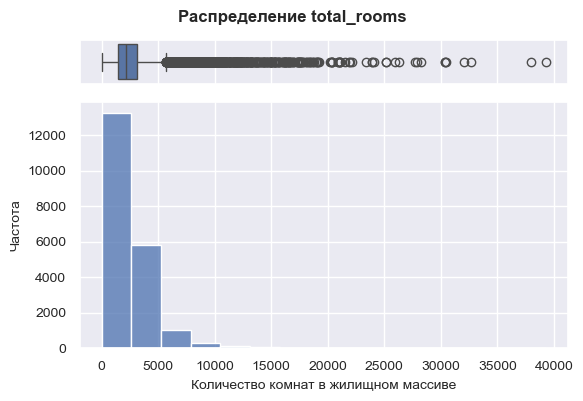

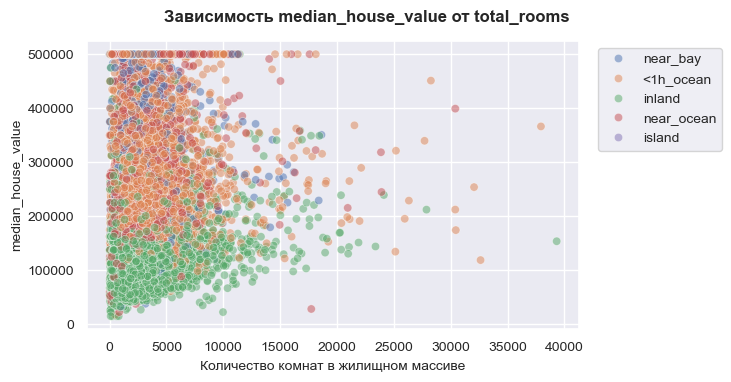

,count,mean,std,min,25%,50%,75%,max
total_rooms,20640.0,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,1246.078921
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [37]:
analyzis_quantity(df['total_rooms'], x_label='Количество комнат в жилищном массиве', 
                  target=target, system=True, hue=df['ocean_proximity'])

В данном признаке мы видим довольно длинный хвост, воспользуемся компрессией, для снижения влияния выбросов.

In [38]:
# Поиск порога сжатия
df['total_rooms'].quantile(0.95)

np.float64(6213.199999999997)

In [39]:
# Компрессия данных
df['total_rooms_comp'] = compress(df['total_rooms'], threshold=6214, coef=0.9)

In [40]:
# Поиск порога сжатия
df['total_rooms_comp'].quantile(0.85)

np.float64(3942.0)

In [41]:
# Компрессия данных
df['total_rooms_comp'] = compress(df['total_rooms_comp'], threshold=3942, coef=0.9)

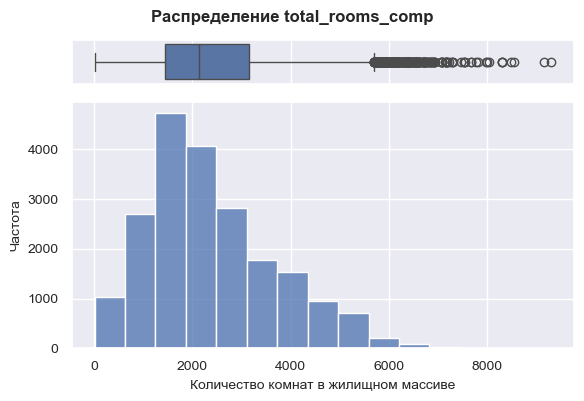

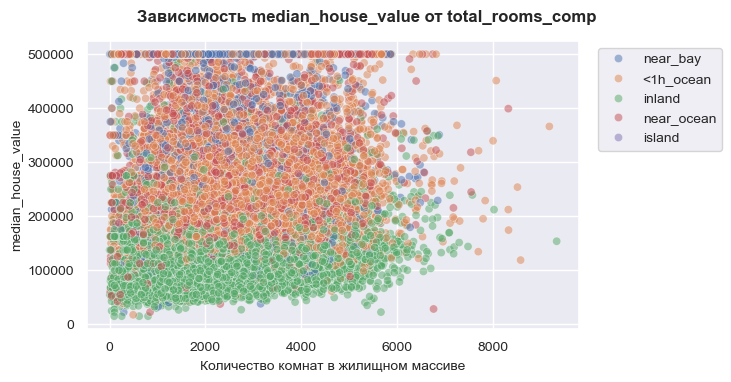

,count,mean,std,min,25%,50%,75%,max
total_rooms_comp,20640.0,2393.766345,1312.957971,2.0,1447.75,2127.0,3148.0,9318.86804


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,282.052041
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [42]:
analyzis_quantity(df['total_rooms_comp'], x_label='Количество комнат в жилищном массиве', 
                  target=target, system=True, hue=df['ocean_proximity'])

In [43]:
# Оценка корреляции с таргетом до и после
print(f"Корреляция до: {df['total_rooms'].corr(df['median_house_value']):.3f}")
print(f"Корреляция после: {df['total_rooms_comp'].corr(df['median_house_value']):.3f}")

Корреляция до: 0.134
Корреляция после: 0.174


Наилучший результат дала последовательная степенная компрессия данных с разным порогом срабатывания: 

- Среднее отклонение **уменьшилось в 2 раза**;
- Квартили распределения **остались без изменений**;
- Максимальное значение **сократилось в 4 раза**;
- Линейная корреляция с таргетом **увеличилась на 30%**.

#### Признак "total_bedrooms":

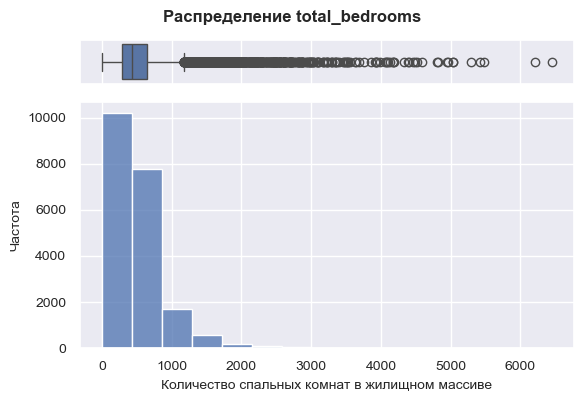

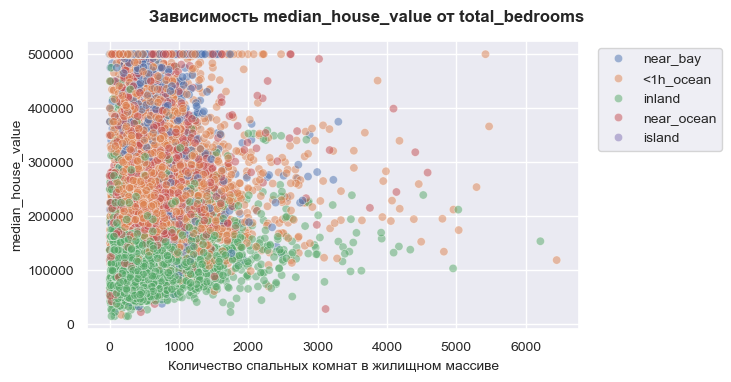

,count,mean,std,min,25%,50%,75%,max
total_bedrooms,20640.0,537.915843,421.143907,1.0,295.0,435.0,647.0,6445.0


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,1118.670759
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [44]:
analyzis_quantity(df['total_bedrooms'], x_label='Количество спальных комнат в жилищном массиве', 
                  target=target, system=True, hue=df['ocean_proximity'])

Ситуация подобна признаку `total_rooms` применим к этому признаку тот же метод компрессии, так как это те же комнаты и чтобы не исказить процентное соотношение мы применяем те же пороги и те же степени сжатия.

In [45]:
# Поиск порога сжатия
df['total_bedrooms'].quantile(0.95)

np.float64(1278.0)

In [46]:
# Компрессия значений 
df['total_bedrooms_comp'] = compress(df['total_bedrooms'], threshold=1278, coef=0.9)

In [47]:
# Поиск порога сжатия
df['total_bedrooms_comp'].quantile(0.85)

np.float64(812.1499999999978)

In [48]:
# Компрессия значений 
df['total_bedrooms_comp'] = compress(df['total_bedrooms_comp'], threshold=812, coef=0.9)

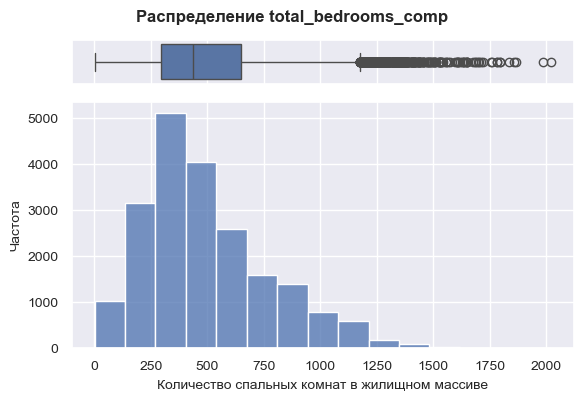

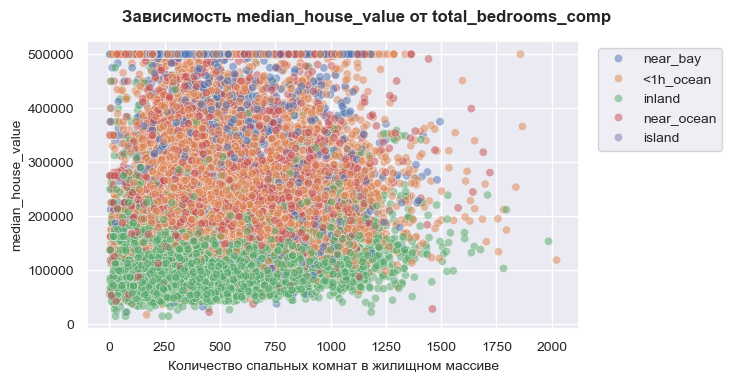

,count,mean,std,min,25%,50%,75%,max
total_bedrooms_comp,20640.0,497.245617,280.066479,1.0,295.0,435.0,647.0,2022.310598


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,356.876039
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [49]:
analyzis_quantity(df['total_bedrooms_comp'], x_label='Количество спальных комнат в жилищном массиве', 
                  target=target, system=True, hue=df['ocean_proximity'])

In [50]:
# Оценка корреляции с таргетом до и после
print(f"Корреляция до: {df['total_bedrooms'].corr(df['median_house_value']):.3f}")
print(f"Корреляция после: {df['total_bedrooms_comp'].corr(df['median_house_value']):.3f}")

Корреляция до: 0.051
Корреляция после: 0.060


Последовательная степенная компрессия данных с разным порогом срабатывания дала следующий результат: 

- Среднее отклонение **уменьшилось в 1.5 раза**;
- Квартили распределения **остались без изменений**;
- Максимальное значение **сократилось в 3 раза**;
- Линейная корреляция с таргетом **увеличилась на 20%**.

#### Признак "population":

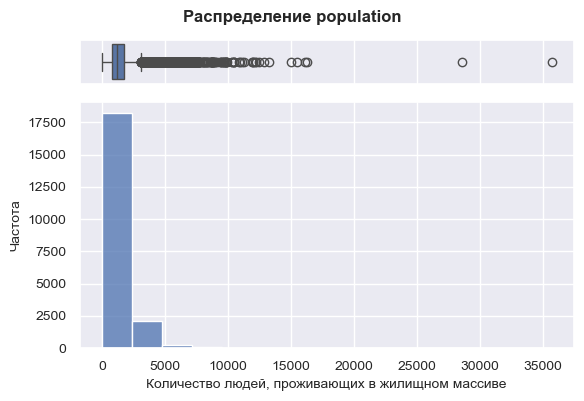

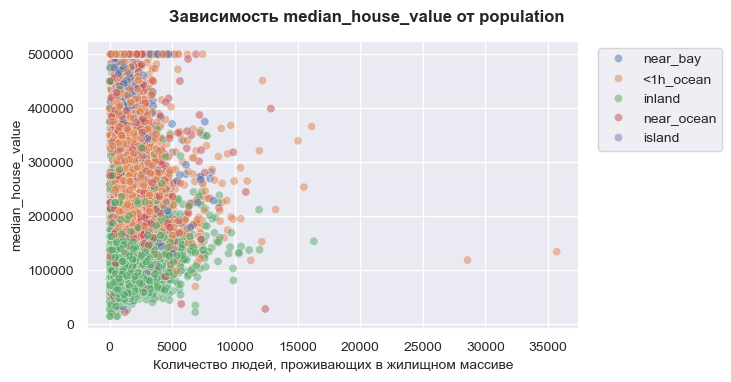

,count,mean,std,min,25%,50%,75%,max
population,20640.0,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,1086.925933
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [51]:
analyzis_quantity(df['population'], x_label='Количество людей, проживающих в жилищном массиве', 
                  target=target, system=True, hue=df['ocean_proximity'])

In [52]:
# Поиск порога сжатия
df['population'].quantile(0.9999)

np.float64(16293.306299999815)

In [53]:
# Компрессия значений
df['population_comp'] = compress(df['population'], threshold=16293, coef=0.5, dry=0.2)

In [54]:
# Поиск порога сжатия
df['population_comp'].quantile(0.98)

np.float64(4573.6600000000035)

In [55]:
# Компрессия значений
df['population_comp'] = compress(df['population_comp'], threshold=4574, coef=0.5, dry=0.5)

In [56]:
# Поиск порога сжатия
df['population_comp'].quantile(0.95)

np.float64(3288.0)

In [57]:
# Компрессия значений
df['population_comp'] = compress(df['population_comp'], threshold=3288, coef=0.9, dry=0.3)

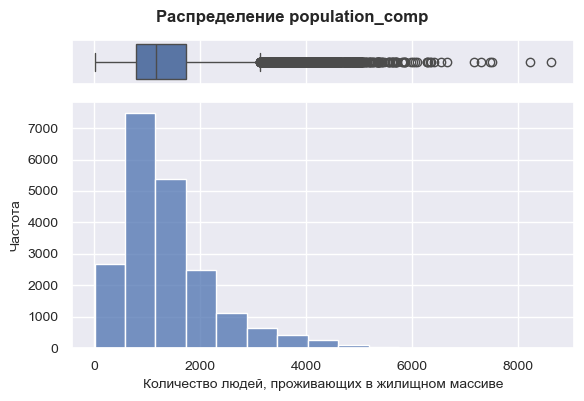

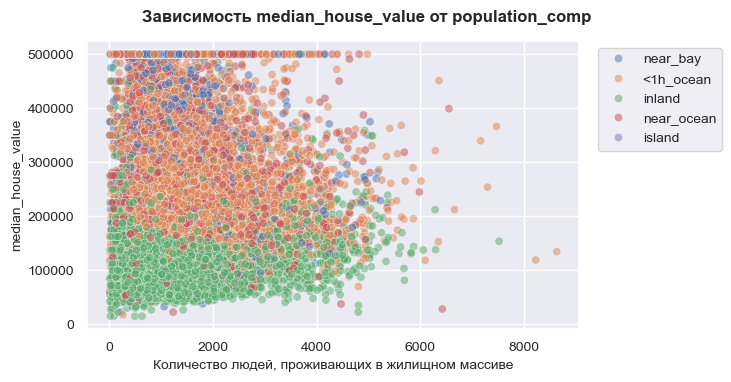

,count,mean,std,min,25%,50%,75%,max
population_comp,20640.0,1383.586033,903.51359,3.0,787.0,1166.0,1725.0,8634.805198


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,658.315483
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [58]:
analyzis_quantity(df['population_comp'], x_label='Количество людей, проживающих в жилищном массиве', 
                  target=target, system=True, hue=df['ocean_proximity'])

In [59]:
# Оценка корреляции с таргетом до и после
print(f"Корреляция до: {df['population'].corr(df['median_house_value']):.3f}")
print(f"Корреляция после: {df['population_comp'].corr(df['median_house_value']):.3f}")

Корреляция до: -0.025
Корреляция после: -0.029


Последовательная степенная компрессия данных с разным порогом срабатывания дала следующий результат: 

- Среднее отклонение **уменьшилось на 20%**;
- Квартили распределения **остались без изменений**;
- Максимальное значение **сократилось в 4 раза**;
- Линейная корреляция с таргетом **увеличилась на 12%**.

#### Признак "households":

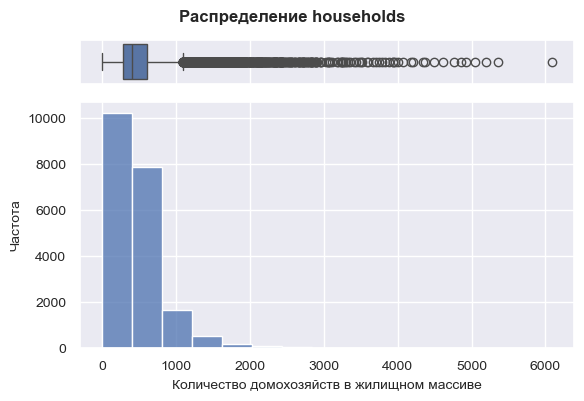

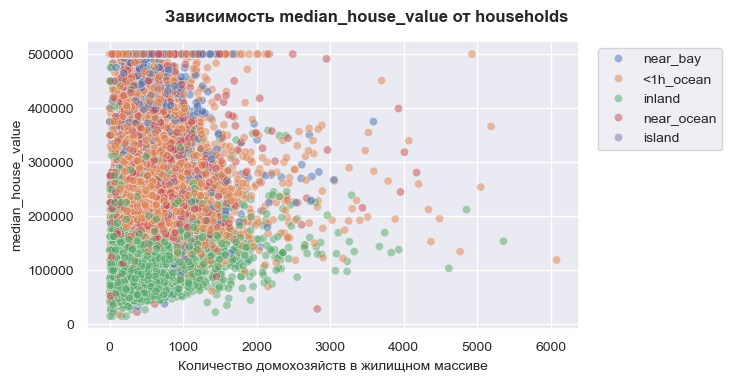

,count,mean,std,min,25%,50%,75%,max
households,20640.0,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,1048.730699
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [60]:
analyzis_quantity(df['households'], x_label='Количество домохозяйств в жилищном массиве', 
                  target=target, system=True, hue=df['ocean_proximity'])

In [61]:
# Поиск порога сжати
df['households'].quantile(0.99)

np.float64(1982.6600000000035)

In [62]:
# Компрессия значений 
df['households_comp'] = compress(df['households'], threshold=1983, coef=0.5, dry=0.3)

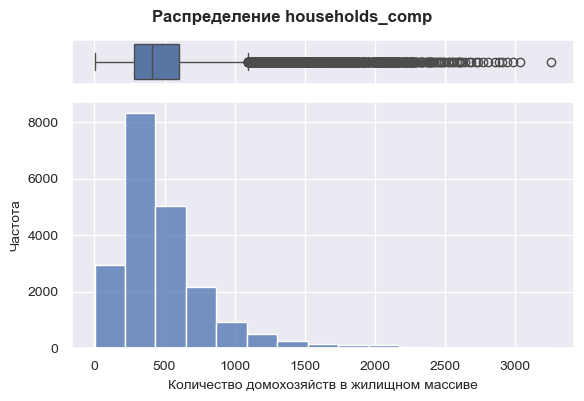

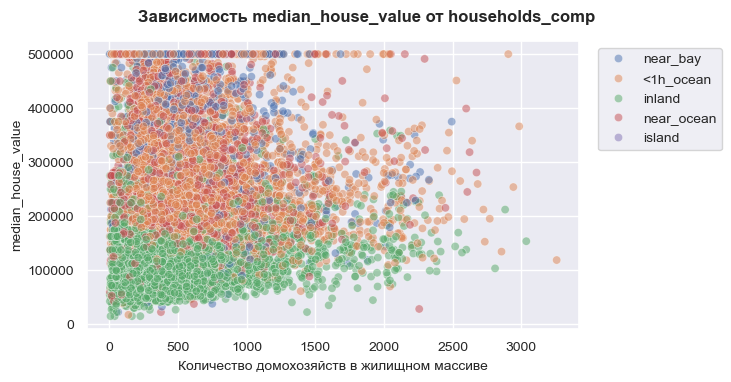

,count,mean,std,min,25%,50%,75%,max
households_comp,20640.0,494.582265,348.848117,1.0,280.0,409.0,605.0,3257.516403


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,878.147196
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [63]:
analyzis_quantity(df['households_comp'], x_label='Количество домохозяйств в жилищном массиве', 
                  target=target, system=True, hue=df['ocean_proximity'])

In [64]:
# Оценка корреляции с таргетом до и после
print(f"Корреляция до: {df['households'].corr(df['median_house_value']):.3f}")
print(f"Корреляция после: {df['households_comp'].corr(df['median_house_value']):.3f}")

Корреляция до: 0.066
Корреляция после: 0.070


Последовательная степенная компрессия данных с разным порогом срабатывания дала следующий результат: 

- Среднее отклонение **уменьшилось на 9%**;
- Квартили распределения **остались без изменений**;
- Максимальное значение **сократилось в 2 раза**;
- Линейная корреляция с таргетом **увеличилась на 6%**.

#### Признак "median_income":

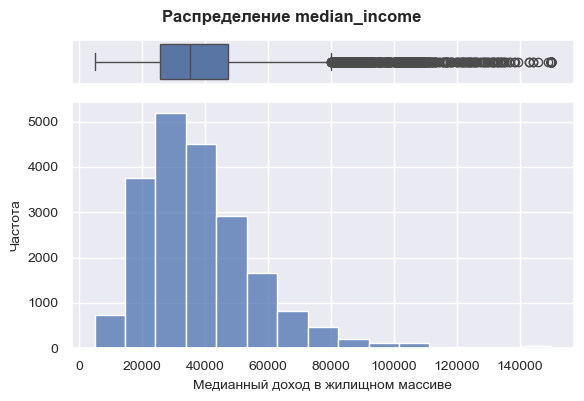

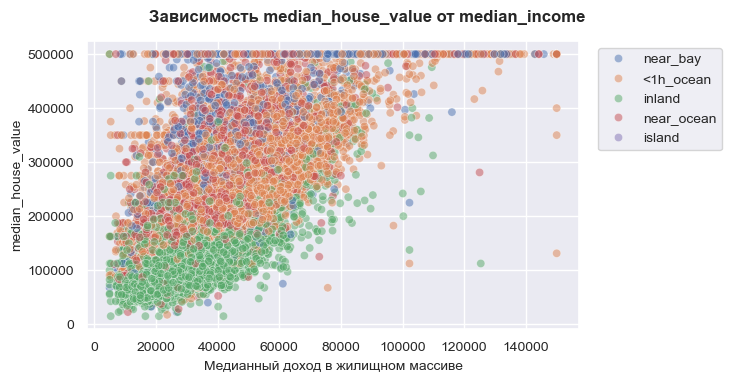

,count,mean,std,min,25%,50%,75%,max
median_income,20640.0,38706.710029,18998.217179,4999.0,25634.0,35348.0,47432.5,150001.0


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,392.8713
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [65]:
analyzis_quantity(df['median_income'], x_label='Медианный доход в жилищном массиве', 
                  target=target, system=True, hue=df['ocean_proximity'])

В данный призак имеет явную линейную зависимость с медианной ценой на жилье, но объекты, где истинная цена на жилье зацензурирована, может путать модель.

#### Признак "median_house_value":

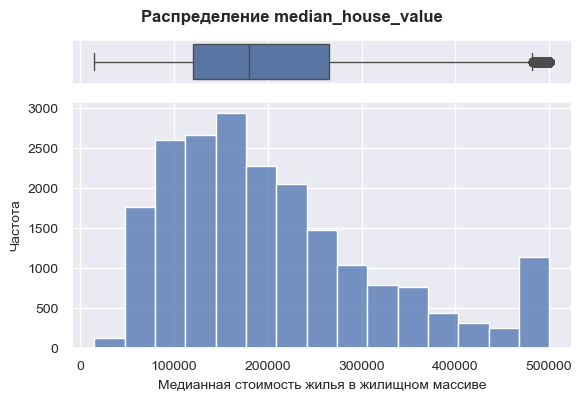

,count,mean,std,min,25%,50%,75%,max
median_house_value,20640.0,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0


,Тест на нормальность распределения (порог=0.05):
,
Статистика:,501.769278
Критические значения:,"[0.576, 0.656, 0.787, 0.918, 1.092]"
Распределение,Не является нормальным


In [66]:
analyzis_quantity(df['median_house_value'], x_label='Медианная стоимость жилья в жилищном массиве')

У нас есть пик на значениях **500001**, что говорит о цензурировании стоимости жилья в элитных районах.

### Категориальные признаки:

#### Признак "ocean_proxinity":

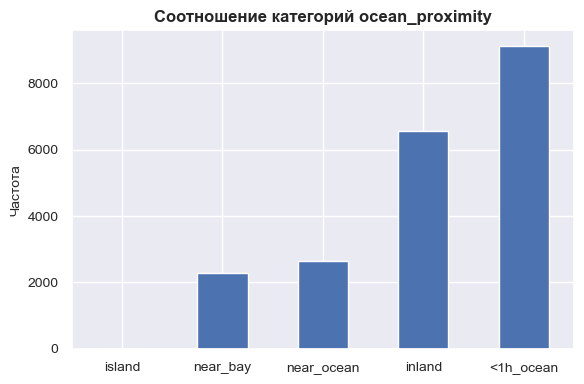

ocean_proximity,count
island,5
near_bay,2290
near_ocean,2658
inland,6551
<1h_ocean,9136


In [67]:
analyzis_category(df['ocean_proximity'])

Количество жилых районов на островах слишком мало, так же, вернувшись к графику долготы и широты возникает вопрос, а нужно ли нам столько категорий, не усложняет ли нам это модель, на этапе `feature engineering` воспользуемся статистическим тестом `ANOVA`, чтобы определить действительно ли в них есть отличие.

### Вывод:

#### Карта цен — это карта городов.


Признаки `longitude` и `latitude` показали, что высокие цены сосредоточены не случайно — они кластеризуются вокруг крупных городов Калифорнии *(Лос-Анджелес, Сан-Франциско, Сан-Диего и т.д.)*.


➤ **Решение**: Создадим новый категориальный признак — `urban_area` — на основе кластеризации координат. Это даст модели "понимание географии" рассматриваемой местности.

---

#### Длинный хвосты распределений количественных признаков.


Большинство числовых признаков (доход, возраст жилья и др.) имеют сильную правую асимметрию + выбросы.


➤ **Решение**: Применили компрессию значений — выбросы больше не доминируют, но информация сохранена и корреляция с тергетом в этих признаках усилена.

---

#### Целевая переменная — не просто ассиметрична, она законно обрезана.


На конце распределения небольшой пик — это цензурирование. В данных нет цен выше определённого порога *(возможно, ограничение сбора или законодательное ограничение)*.


➤ **Проблема**: Модель может ошибочно интерпретировать этот пик как реальную «пиковую» цену.


➤ **Статус**: Решение пока не найдено — но мы его не игнорируем. Проверим влияние на валидации и рассмотрим методы работы с цензурированными данными. 

---

#### `Ocean_proximity` — но стоит ли делить на 5 категорий?


Признак `ocean_proximity` имеет 5 уровней, но районы на островах — редкость. Мы подозреваем, что некоторые категории не несут смысловой нагрузки.


➤ **Решение**: Используем `ANOVA`, чтобы проверить — действительно ли все категории отличаются по цене. Если нет — объединим их. Меньше категорий = проще модель = меньше переобучения. 

## Корреляционный анализ:

В виду того, что мы предполагаем, что компрессия улучшает взаимосвязь между признаками, будем работать далее с компрессированными признаками, если потребуется их преобразовать дополнительно, будем применять те же действия и к оригинальным.

In [68]:
# Списки признаков
feature_raw = ['total_rooms', 
               'total_bedrooms',
               'population',
               'households']

feature_comp = ['total_rooms_comp',
                'total_bedrooms_comp',
                'population_comp',
                'households_comp']

feature_num = ['longitude',
               'latitude',
               'housing_median_age',
               'median_income']

feature_cat = ['ocean_proximity']

target = ['median_house_value']

### Матрица корреляции:

Оценим линейную зависимость между признаками.

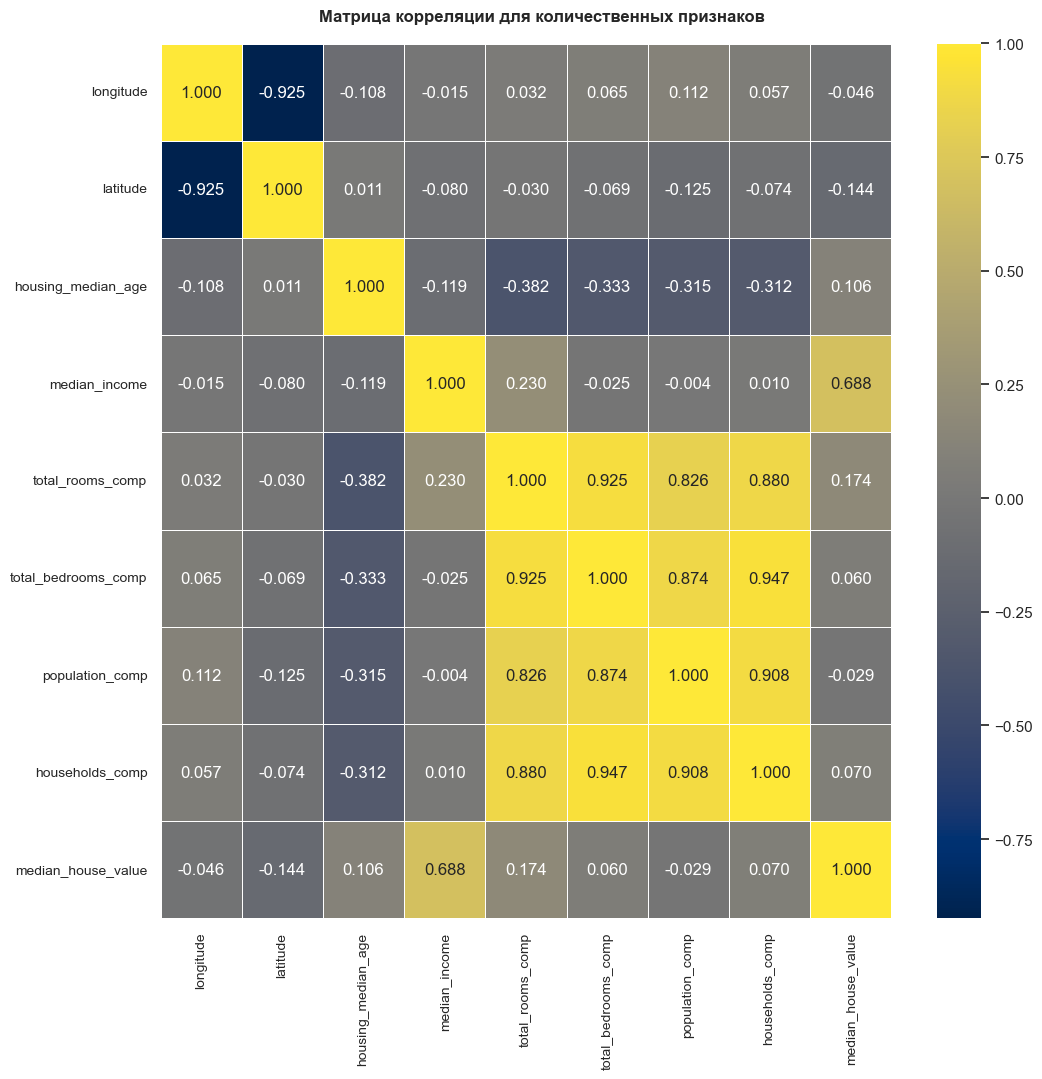

In [69]:
# Построение матрицы корреляции
fig, ax = plt.subplots(figsize=(11, 11))
sns.heatmap(df[feature_num + feature_comp + target].corr(), annot=True, 
            fmt='.3f', linewidths=.5, cmap='cividis', ax=ax)

# Настройка заголовка и подписей
fig.suptitle('Матрица корреляции для количественных признаков', fontweight='bold', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.xticks(rotation=90)

# Отображаем график
plt.tight_layout()
plt.show()

Наблюдаем сильную зависимость между признаками `total_rooms_comp`, `total_bedrooms_comp`, `population_comp`, `households_comp`, проверим их на наличие мультиколлениарности между ними.

### VIF-фактор:

In [70]:
# VIF-фактор
vif_factor(df, feature_comp)

,input attribute,vif
0,total_rooms_comp,28.827029
1,total_bedrooms_comp,55.661096
2,population_comp,18.827544
3,households_comp,32.932561


У всех признаков значения выше **10**, что говорит о наличие мультиколлинеарности.

Всех их объединяет общее количество домойхозяйств, разделим первые 3 признака на `households_comp`, чтобы получить среднее значение для каждого жилого массива.

In [71]:
# Создание новых признаков
df['mean_rooms_comp'] = df['total_rooms_comp'] / df['households_comp']
df['mean_bedrooms_comp'] = df['total_bedrooms_comp'] / df['households_comp']
df['mean_population_comp'] = df['population_comp'] / df['households_comp']

In [72]:
# Повторная оценка мультиколлинеарности
# Список признаков
multicol = ['households_comp',
            'mean_rooms_comp',
            'mean_bedrooms_comp',
            'mean_population_comp']

In [73]:
# VIF-фактор
vif_factor(df, multicol)

,input attribute,vif
0,households_comp,1.985559
1,mean_rooms_comp,21.863538
2,mean_bedrooms_comp,23.050539
3,mean_population_comp,1.136055


У средних количеств комнат и спален еще есть сильная зависимость, избавимся от нее возведением одного признака в степень.

In [74]:
# Создание новых признаков
df['mean_bedrooms_comp^2'] = df['mean_bedrooms_comp'] ** 2

In [75]:
# Повторная оценка мультиколлинеарности
# Список признаков
feature_comp = ['households_comp',
                'mean_rooms_comp',
                'mean_bedrooms_comp^2',
                'mean_population_comp']

# VIF-фактор
vif_factor(df, feature_comp)

,input attribute,vif
0,households_comp,2.051589
1,mean_rooms_comp,2.567759
2,mean_bedrooms_comp^2,1.321536
3,mean_population_comp,1.143200


Мы избавились от мультиколлинеарности. Повторим те же действия для оригинальных признаков.

In [76]:
# Создание новых признаков
df['mean_rooms'] = df['total_rooms'] / df['households']
df['mean_bedrooms^2'] = (df['total_bedrooms'] / df['households']) ** 2
df['mean_population'] = df['population'] / df['households']

In [77]:
# Список признаков
feature_raw = ['households',
               'mean_rooms',
               'mean_bedrooms^2',
               'mean_population']

# VIF-фактор
vif_factor(df, feature_raw)

,input attribute,vif
0,households,2.167185
1,mean_rooms,2.659057
2,mean_bedrooms^2,1.326902
3,mean_population,1.076839


Повторно рассмотрим матрицу корреляции.

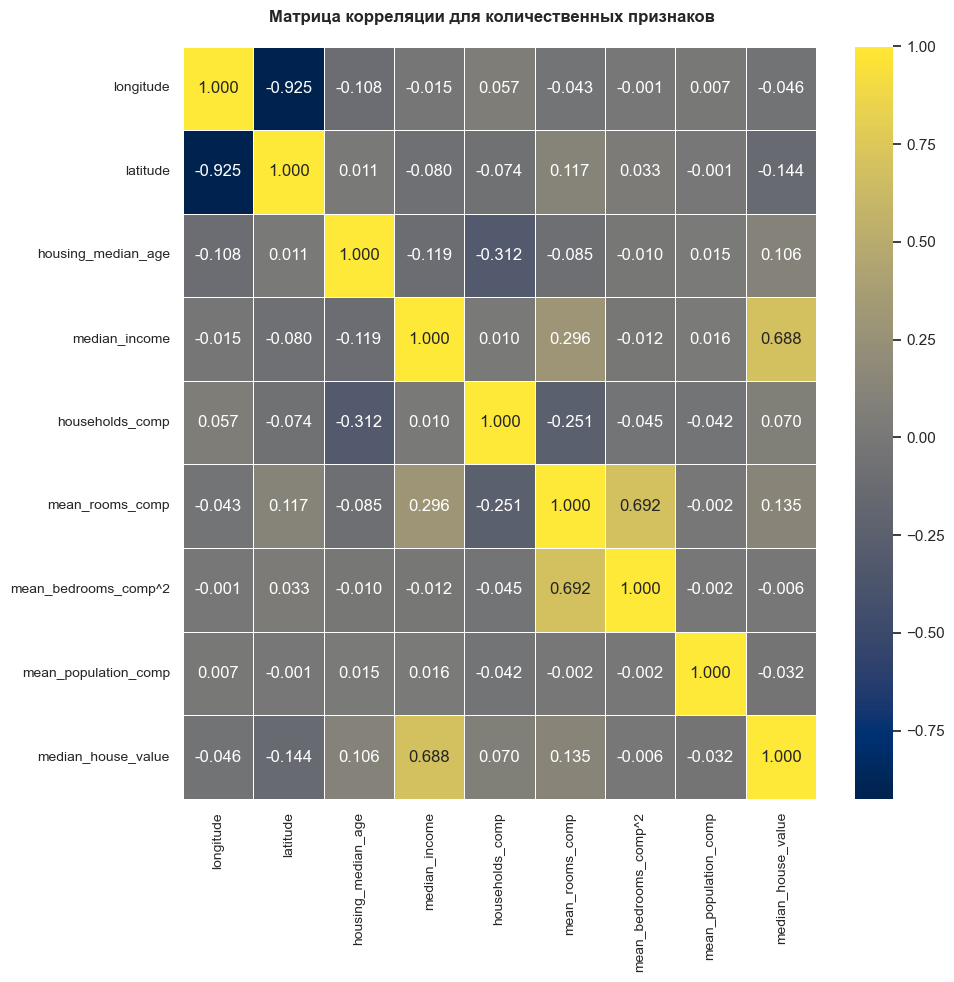

In [78]:
# Построение матрицы корреляции
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(df[feature_num + feature_comp + target].corr(), annot=True, 
            fmt='.3f', linewidths=.5, cmap='cividis', ax=ax)

# Настройка заголовка и подписей
fig.suptitle('Матрица корреляции для количественных признаков', fontweight='bold', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.xticks(rotation=90)

# Отображаем график
plt.tight_layout()
plt.show()

Далее рассмотрим нелинейные зависимости и допольнительно с категориальным признаком.

### Матрица Phik:

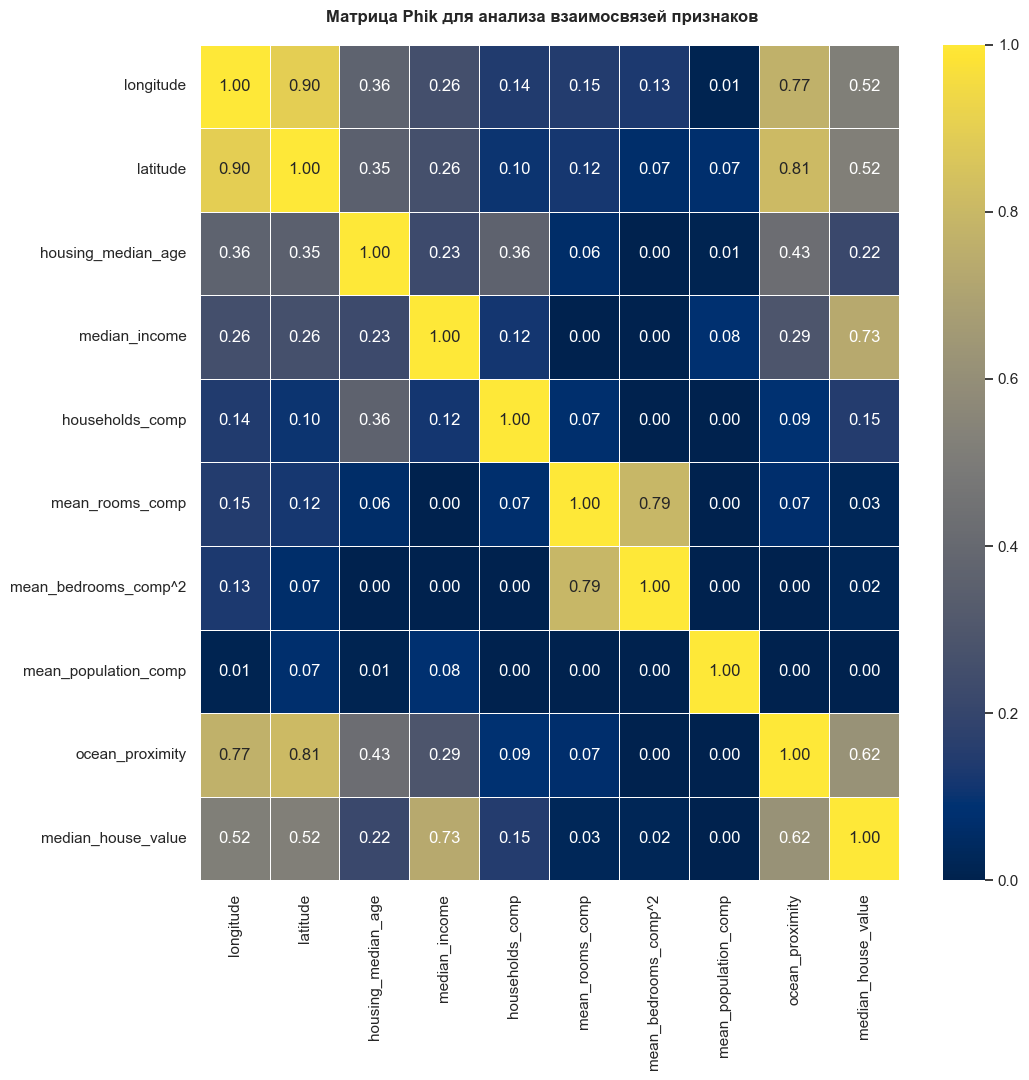

In [87]:
# Список с непрервными количественными значениями
interval_cols = feature_num + feature_comp + target
# Список рассматриваемых признаков
feature_work = feature_num + feature_comp + feature_cat + target

# Строим тепловую карту
f, ax = plt.subplots(figsize=(11, 11))
sns.heatmap(df[feature_work].phik_matrix(interval_cols=interval_cols), annot=True, 
            fmt='.2f', linewidths=.5, cmap='cividis', ax=ax)

# Настройка заголовка и подписей
f.suptitle('Матрица Phik для анализа взаимосвязей признаков', fontweight='bold', fontsize=12)

# Отображаем график
plt.tight_layout()
plt.show()

Признак `ocean_proximity` показывает сильную корреляцию с таргетом.

У нас остались еще признаки долготы и широты, которые сильно взаимосвязаны, их преобразуем в новый категориальный признак с помощью кластеризации.

Признаки `mean_rooms_comp` и `mean_bedrooms_comp^2` еще сильно связаны, но с таргетом не сильно, попробуем усилить их влияние через анализ независимых компонент, получив 1 или 2 признака с более сильной связью с таргетом.

Для продолжения анализа перейдем к этапу `feature engineering`.

### Feature engineering:

#### Признак "urban_area":

Наша цель, создать категориальных признак, которых будет делить данные на кластеры, которые должны служить делению на города и прилегающей к ним местность.

In [80]:
# Преобразования долготы и широты в 3д координаты
coords_3d = to_3d(df['latitude'], df['longitude'])

Чтобы выбрать оптимальное количество кластеров, сначала рассмотрим метод локтя.

In [81]:
# Получаем данные о inertia
n_clusters_range = range(1, 25)
inertias = []

for n in n_clusters_range:
    kmeans = MiniBatchKMeans(n_clusters=n, random_state=RANDOM_STATE)
    kmeans.fit(coords_3d)
    inertias.append(kmeans.inertia_)

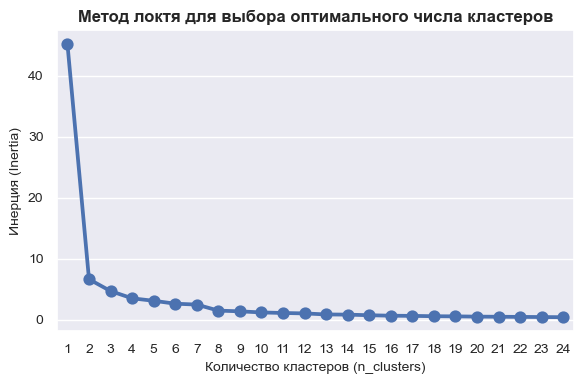

In [82]:
# Строим график
fig = plt.subplots(figsize=(6, 4))
sns.pointplot(x=n_clusters_range, y=inertias)

# Настройка заголовка и подписей
plt.title('Метод локтя для выбора оптимального числа кластеров', fontweight='bold', fontsize=12)
plt.xlabel('Количество кластеров (n_clusters)', fontsize=10)
plt.ylabel('Инерция (Inertia)', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Вывод графика
plt.tight_layout()
plt.show()

Метод локтя указывает, что оптимальное кличество кластеров ровно **2 - 4**, но это мало, ранее в исследовательском анализе мы видели эти 2 явных района, но при визуализации самой карты эти районы никак не помогут лучше определять медианную цену жилого массива, разделим наши координаты на населенные пункты.

Согласно открытым источникам на момент переписи населения в 1990 году в Калифорнии было 26 крупных городов, где население свыше 100000 человек, наше предположение строится на том, что города, это скопления жилых массивов, следовательно алгоритм и объединит эти массивы в кластеры, а соответственно в города и близлежащую к ним местность.

In [120]:
# Инициализируем модель для кластеризации
kmeans = MiniBatchKMeans(n_clusters=26, random_state=RANDOM_STATE)

In [121]:
# Получаем новый признак
df['urban_area'] = kmeans.fit_predict(coords_3d)

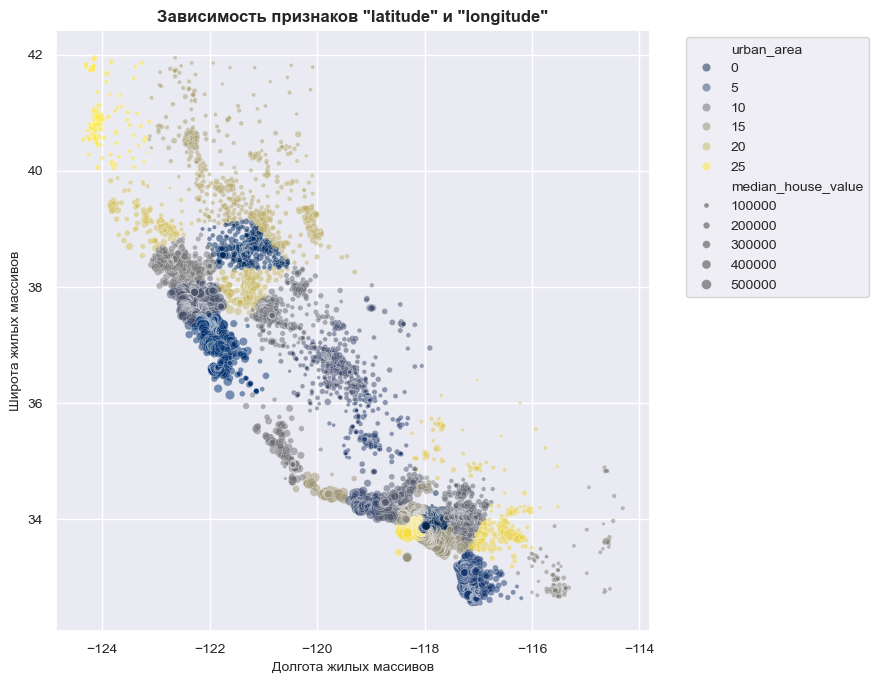

In [122]:
# Визуализация итогов кластеризации
# Построение графика
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(x=df['longitude'], y=df['latitude'], hue=df['urban_area'], 
                size=df['median_house_value'], sizes=(5, 50), alpha=0.5, palette='cividis', ax=ax)

# Настройка заголовков и подписей
plt.title('Зависимость признаков "latitude" и "longitude"', fontsize=12, fontweight='bold')
ax.set_xlabel('Долгота жилых массивов', fontsize=10)
ax.set_ylabel('Широта жилых массивов', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Отображение графика
fig.tight_layout()
plt.show()

![Карта Калифорнии](images/california_map.jpg)

In [125]:
# Рассмотрим описательную статистику по новым категориям
claster_table = df.groupby('urban_area')['median_house_value'].agg(['count', 'min', 'mean', 'max'])
claster_table.sort_values(by='mean', ascending=False)

Описательная статистика медианной стоимости жилья по категориям "urban_area":


,count,min,mean,max
urban_area,,,,
16,185,37500.0,326636.891892,500001.0
2,1465,40000.0,287971.359727,500001.0
14,2359,17500.0,271140.218313,500001.0
15,1055,45000.0,270204.918483,500001.0
7,2680,22500.0,267466.941791,500001.0
8,815,83300.0,251151.363190,500001.0
5,295,52500.0,250862.088136,500001.0
24,2053,46700.0,214553.721383,500001.0
0,1488,14999.0,204337.172715,500001.0


Во всех кластерах отличается средняя медианная цена на жилье — это хороший признак, но почти во всех есть зацензурированные жилые массивы, возможно имеет смысл попробовать сделать вариант датасета без этих объектов. 

# ОСТАНОВИЛИСЬ ТУТ!

#### Признак "mean_rooms" и "mean_bedrooms":

Эти признаки дают слабое влияние на таргет, а между собой сильно, попробуем применить в ним анализ независимых компонент.

In [ ]:
# Инициализация ICA
ica = FastICA(n_components=2, random_state=RANDOM_STATE)

In [ ]:
# Признаки на преобразование
rooms = df[['mean_rooms', 'mean_bedrooms^2']]

In [ ]:
# Трансформируем признаки
new_rooms = ica.fit_transform(rooms)

In [ ]:
# Добавляем в датафрейм
df['rooms_1'] = new_rooms[:, 0]
df['rooms_2'] = new_rooms[:, 1]

Так как новые признаки это дублирование информации из оригинальных, удаляем их.

In [ ]:
df.drop(['mean_rooms', 'mean_bedrooms^2'], axis=1, inplace=True)

#### Признак "ocean_proximity":

Проверим с помощью теста `ANOVA` действительно ли отличаются все категории в признаке `ocean_proximity`.

In [ ]:
# Выделяем группу для анализа
near_ocean = df[df['ocean_proximity'] == 'near_ocean']['median_house_value']
ocean_1h = df[df['ocean_proximity'] == '<1h_ocean']['median_house_value']
inland = df[df['ocean_proximity'] == 'inland']['median_house_value']
near_bay = df[df['ocean_proximity'] == 'near_bay']['median_house_value']
island = df[df['ocean_proximity'] == 'island']['median_house_value']

In [ ]:
# Тест ANOVA
f_stat, p_val = stats.f_oneway(near_ocean, ocean_1h, inland, near_bay, island)
print(f"ANOVA p-value: {p_val:.4f}")

alpha = 0.05

if p_val < alpha:
    print("ANOVA значим → переходим к Tukey HSD")
else:
    print("ANOVA не значим → различий между группами нет, post-hoc не нужен")

In [ ]:
# Тест Tukey HSD
tukey = pairwise_tukeyhsd(df['median_house_value'], df['ocean_proximity'], alpha=alpha)
print(tukey)

Видим, что категория `island` не имеет отличий от категорий, которые находятся рядом с океаном, упростим этот признак и присоединим эту группу к ближайшей к ней географически, а именно к `near_ocean`.

In [ ]:
# Заменям значения
df['ocean_proximity_new'] = df['ocean_proximity'].map(lambda x: 'near_ocean' if x == 'island' else x)

In [ ]:
# Список с непрервными количественными значениями
interval_cols = ['housing_median_age',
                 'median_income',
                 'median_house_value',
                 'households_comp',
                 'mean_population',
                 'rooms_1', 
                 'rooms_2']

# Строим тепловую карту
f, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(df.phik_matrix(interval_cols=interval_cols), annot=True, 
            fmt='.3f', linewidths=.5, cmap='cividis', ax=ax)

# Настройка заголовка и подписей
f.suptitle('Матрица Phik для анализа взаимосвязей признаков', fontsize=14)

# Отображаем график
plt.tight_layout()
plt.show()

Несмотря на то, что статистические тесты указывали, что разницы нет, объединение категорий приводит к снижению зависимости с таргетом, чего мы не хотим, откажемся от объединения категорий и оставим признак без изменений.

In [ ]:
# Удаляем признак
df.drop('ocean_proximity_new', axis=1, inplace=True)

#### Сравнение линейной и монотонной корреляции:

In [ ]:
# Количественные признаки
num_col = df.columns.drop('ocean_proximity').tolist()

# Построение матрицы корреляции методом Пирсона
fig_1, ax_1 = plt.subplots(figsize=(10, 2))
sns.heatmap(df[num_col].corr().iloc[[1]], annot=True, 
            fmt='.3f', linewidths=.5, cmap='cividis', ax=ax_1)

# Настройка заголовка и подписей
fig_1.suptitle('Матрица корреляции для количественных признаков (Пирсон)', fontweight='bold', fontsize=12)
ax_1.set(xticklabels=[])

# Отображаем график
plt.tight_layout()
plt.show()

# Построение матрицы корреляции методом Спирмена
fig_2, ax_2 = plt.subplots(figsize=(10, 3.5))
sns.heatmap(df[num_col].corr(method='spearman').iloc[[1]], annot=True, 
            fmt='.3f', linewidths=.5, cmap='cividis', ax=ax_2)

# Настройка заголовка и подписей
fig_2.suptitle('Матрица корреляции для количественных признаков (Спирмен)', fontweight='bold', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.xticks(rotation=90)

# Отображаем график
plt.tight_layout()
plt.show()

Мы видим, что у признаков `mean_population` и `rooms_2` есть монотонная зависимость, а линейной не наблюдается, что говогрит о нелинейной зависимости, рассмотрим их взаимосвязь с таргетом и попробуем с помощью преобрзований добиться линейной зависимости. 

#### Признак "mean_population":

In [ ]:
# Строим график с линией тренда
sns.lmplot(x='mean_population', y='median_house_value', 
           data=df, ci=95, height=5, aspect=1.4)

# Настройка загловка и подписей
plt.title('Линии тренда относительно каждой категории', fontweight='bold', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)

# Вывод графика
plt.tight_layout()
plt.show()

У нас есть сильные выбросы, уменьшим их.

In [ ]:
df['mean_population_comp'] = log_compress(df['mean_population'], threshold=20, scale=1)

In [ ]:
df['mean_population_comp'] = power_compress(df['mean_population_comp'], threshold=6, power=0.5)

In [ ]:
# Строим график с линией тренда
sns.lmplot(x='mean_population_comp', y='median_house_value', hue='ocean_proximity',
           data=df, ci=95, height=5, aspect=1.4, legend=False)

# Настройка загловка и подписей
plt.title('Линии тренда относительно каждой категории', fontweight='bold', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.ylim(0, 501000)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Вывод графика
plt.show()

Подберем наилучшие коэффициенты для формулы

In [ ]:
pop = df['mean_population_comp']

In [ ]:
# Подбор коэфициент степени экспоненты
for i in [0.91, 0.92, 0.93, 0.94, 0.95]:
    df['population_comfort_index'] = pop * 100 * np.exp(-i * pop)
    print(df['population_comfort_index'].corr(df['median_house_value']))

Первый коэффициент подобран и равен **0.93**.

In [ ]:
# Подбор коэфициента экспоненты
for i in [1, 10, 100, 1000, 10000]:
    df['population_comfort_index'] = pop * i * np.exp(-0.93 * pop)
    print(df['population_comfort_index'].corr(df['median_house_value']))

Данный коэфициент никак не влияет на корреляцию, оставим 100 для удобства.

Добавления смещения функции значительно на корреляцию не влияет.

In [ ]:
# Убираем нелинейность
df['population_comfort_index'] = pop * 100 * np.exp(-0.93 * pop)

In [ ]:
# Строим график с линией тренда
sns.lmplot(x='population_comfort_index', y='median_house_value', hue='ocean_proximity',
           data=df, ci=95, height=5, aspect=1.4, legend=False)

# Настройка загловка и подписей
plt.title('Линии тренда относительно каждой категории', fontweight='bold', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.ylim(0, 501000)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Вывод графика
plt.show()

In [ ]:
df['population_comfort_index'].corr(df['median_house_value'])

Добиться почти той же корреляции не удалось, но мы существенно ее увеличили.

#### Признак "rooms_2":

Строим график взаимосвязи признака с таргетом с линиями тренда.

In [ ]:
# Строим график с линией тренда
sns.lmplot(x='rooms_2', y='median_house_value', hue='ocean_proximity',
           data=df, ci=95, height=5, aspect=1.4, legend=False)

# Настройка загловка и подписей
plt.title('Линии тренда относительно каждой категории', fontweight='bold', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.ylim(0, 501000)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Вывод графика
plt.show()

Есть сильны выбросы, избавимся от них.

In [ ]:
df['rooms_2'].quantile(0)

In [ ]:
df['rooms_2'] = -df['rooms_2']

In [ ]:
df['rooms_2_comp'] = log_compress(df['rooms_2'], threshold=7, scale=1)

In [ ]:
df['rooms_2_comp'] = log_compress(df['rooms_2_comp'], threshold=0.4, scale=0.2)

In [ ]:
# Строим график с линией тренда
sns.lmplot(x='rooms_2_comp', y='median_house_value', hue='ocean_proximity',
           data=df, ci=95, height=5, aspect=1.4, legend=False)

# Настройка загловка и подписей
plt.title('Линии тренда относительно каждой категории', fontweight='bold', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.ylim(0, 501000)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Вывод графика
plt.show()

In [ ]:
df['rooms_2_comp'].corr(df['median_house_value'])

После сжатия значений мы вернули линейную зависимость.

In [ ]:
room = df['rooms_2_comp']

In [ ]:
for i in [5.83, 5.84, 5.85, 5.86, 5.87]:
    df['rooms_2_line'] = room * 100 * np.exp(-i * room)
    print(df['rooms_2_line'].corr(df['median_house_value']))

In [ ]:
df['rooms_2_line'] = df['rooms_2_comp'] * 100 * np.exp(-5.85 * df['rooms_2_comp'])

In [ ]:
# Строим график с линией тренда
sns.lmplot(x='rooms_2_line', y='median_house_value', hue='ocean_proximity',
           data=df, ci=95, height=5, aspect=1.4, legend=False)

# Настройка загловка и подписей
plt.title('Линии тренда относительно каждой категории', fontweight='bold', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.ylim(0, 501000)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Вывод графика
plt.show()

In [ ]:
df['rooms_2_line'].corr(df['median_house_value'])

Дополнительно проверим и второй признак по комнатам.

In [ ]:
# Строим график с линией тренда
sns.lmplot(x='rooms_1', y='median_house_value', hue='ocean_proximity',
           data=df, ci=95, height=5, aspect=1.4, legend=False)

# Настройка загловка и подписей
plt.title('Линии тренда относительно каждой категории', fontweight='bold', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.ylim(0, 501000)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Вывод графика
plt.show()

Здесь просто избавимся от выбросов.

In [ ]:
df['rooms_1_comp'] = log_compress(df['rooms_1'], threshold=3, scale=0.01)

In [ ]:
df['rooms_1_comp'] = -df['rooms_1_comp']

In [ ]:
df['rooms_1_comp'] = log_compress(df['rooms_1_comp'], threshold=2, scale=0.6)

In [ ]:
# Строим график с линией тренда
sns.lmplot(x='rooms_1_comp', y='median_house_value', hue='ocean_proximity',
           data=df, ci=95, height=5, aspect=1.4, legend=False)

# Настройка загловка и подписей
plt.title('Линии тренда относительно каждой категории', fontweight='bold', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.ylim(0, 501000)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Вывод графика
plt.show()

In [ ]:
df['rooms_1_comp'].corr(df['median_house_value'])

### Оценка корреляции после feature_engineering:

In [ ]:
num_col = ['median_income', 'median_house_value',
           'households_comp', 'population_comfort_index',
           'rooms_2_line', 'rooms_1_comp']
# Построение матрицы корреляции
fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(df[num_col].corr(), annot=True, 
            fmt='.3f', linewidths=.5, cmap='cividis', ax=ax)

# Настройка заголовка и подписей
fig.suptitle('Матрица корреляции для количественных признаков', fontweight='bold', fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.xticks(rotation=90)

# Отображаем график
plt.tight_layout()
plt.show()

Есть высокие значения корреляции между входными признаками, проверим `VIF-фактор`.

In [ ]:
vif_col = num_col
vif_col.remove('median_house_value')

In [ ]:
vif_factor(df, vif_col)

Все значения находятся до **10**, можем не переживать о мультиколлинеарности.

In [ ]:
# Список с непрервными количественными значениями
interval_cols = ['median_income',
                 'median_house_value',
                 'households_comp',
                 'population_comfort_index',
                 'rooms_2_line',
                 'rooms_1_comp']
filter_col = ['median_income',
              'ocean_proximity',
              'median_house_value',
              'households_comp',
              'house_age_cat',
              'urban_area',
              'population_comfort_index',
              'rooms_2_line',
              'rooms_1_comp']

# Строим тепловую карту
f, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(df[filter_col].phik_matrix(interval_cols=interval_cols), annot=True, 
            fmt='.3f', linewidths=.5, cmap='cividis', ax=ax)

# Настройка заголовка и подписей
f.suptitle('Матрица Phik для анализа взаимосвязей признаков', fontsize=14)

# Отображаем график
plt.tight_layout()
plt.show()

In [ ]:
# Удаляем все неактуальные признаки
# Список на удаление
drop_lst = ['mean_population', 
            'rooms_1',
            'rooms_2',
            'mean_population_comp',
            'rooms_2_comp']

df.drop(drop_lst, axis=1, inplace=True)

### Вывод:

В данном блоке мы использовали несколько техонологий, для преобразования входных признаков с целью усиления линейной корреляции с таргетом:

- `median_income` — имел сильную линейную зависимость с таргетом, оставили без изменений.
- `ocean_proximity` — проверили с помощью статистических тестов возможность уменьшить количество категорий в признаке, несмотря на полученную схожесть некоторых категорий, их объединение приводило к снижению зависимости с таргетом, данный признак оставили без изменений.
- `median_house_value` — таргет, признак не изменялся.
- `households_comp` — данный признак только компрессировался для снижения влияния выбросов.
- `house_age_cat` — признак с медианным возрастом домов в жилом массиве, но сократили количество категорий до 6, данный подход помог усилить зависимость с таргетом на **5%** и дополнительно снизит сложность для модели.
- `urban_area` — новый признак, который учитывает географическое положение жилого массива и медианный доход его жителей, данный признак показал сильную зависимость с таргетом - **0.778**. Данный категориальный признак сильно коррелирует с признаком `median_income`. Изучив данный вопрос, пришел к выводу, что это только поможет модели, данный вопрос изучим при анализе обученной модели.
- `population_comfort_index` — новый признак, полученный из среднего количества проживающих людей в жилом массиве, в данных была обнаружена колоколовидная зависимость, путем математического преобразования получилось добиться линейной зависимость и вместо **0.028** получили значение линейной корреляции **0.28** — **усиление связи в 10 раз**. На данный момент данный признак интерпретируется, как индекс комфортности плотности населения в жилом районе.
- `rooms_1_comp` — первая независимая компонента, полученная и признаков `mean_rooms` и `mean_bedrooms`, на данном этапе мы можем его интерпретировать, как фактор отвечающий за количество комнат, так как он изначально линейно связан с таргетом, что говорит, чем больше комнат, тем выше цена на недвижимость, путем компрессирования данных, удалось усилить линейную зависимость с таргетом.
- `rooms_2_line` — первая независимая компонента, полученная и признаков `mean_rooms` и `mean_bedrooms`, в данных так же была обнаружено колоколовидная зависиомсть с таргетом и путем математических преобразований добились линейной зависимости с таргетом и вместо **0.023** получили значение линейной корреляции **0.416** — **усиление связи в 20 раз**. На данный момент этот признак можно интепретировать, как индекс удовлетворенности количеством спальных комнат.

Следующим шагом будет обучить модель и проверить на сколько выполненные шаги влияют на предсказательсную способность модели.

### Обучение модели:

In [ ]:
df.head()

In [ ]:
df_2 = df.query('median_house_value != 500001')

In [ ]:
training = df_2[['ocean_proximity', 'median_income', 'population_comfort_index', 'house_age_cat']]
target = df_2['median_house_value']

In [ ]:
# разделение признаков на категории
numeric_col = ['median_income', 'population_comfort_index']
ordinal_col = ['house_age_cat']
ohe_col = ['ocean_proximity']

In [ ]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', OneHotEncoder(handle_unknown='ignore', 
                              sparse_output=False, drop='first'), ohe_col),
        ('num', StandardScaler(), numeric_col)
    ],  remainder='passthrough', 
        force_int_remainder_cols=False)

In [ ]:
pipe_final = Pipeline(
    [
     ('preprocessor', data_preprocessor), 
     ('models', ElasticNet())
    ])

In [ ]:
param_grid = {
    'models': [Lasso(max_iter=10000, random_state=RANDOM_STATE)], 
    'models__alpha': [0.001, 0.01, 0.1, 1.0, 10]
    }

In [ ]:
# Поиск лучшей модели и ее гиперпараметров
test_model = GridSearchCV(
    pipe_final, 
    param_grid, 
    cv=4, 
    scoring='r2', 
    n_jobs=1, 
)
test_model.fit(traning, target)

In [ ]:
model_search = pd.DataFrame(test_model.cv_results_).sort_values(by='rank_test_score')

In [ ]:
model_search.head(5)